<a href="https://colab.research.google.com/github/dudinha-web/fundamentos-de-ia/blob/main/Aula_11_dengue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Casos de Dengue no Brasil

In [1]:
# Bibliotecas essenciais para ciência de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo visual dos gráficos
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12


In [2]:
# Carregar os dados
df = pd.read_csv('/content/DENGBR26.csv', encoding='latin1', low_memory=False)
df.head(3)


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,...,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W
0,2,A90,2026-01-05,202601,2026,32,320500,32002,2499495.0,2026-01-04,...,0.0,0.0,0.0,0.0,0.0,0.0,2026-01-05,0,0.0,0.0
1,2,A90,2026-01-05,202601,2026,32,320520,32002,4676874.0,2026-01-05,...,0.0,0.0,0.0,0.0,0.0,0.0,2026-01-05,0,0.0,0.0
2,2,A90,2026-01-05,202601,2026,32,320500,32002,2522772.0,2026-01-05,...,0.0,0.0,0.0,0.0,0.0,0.0,2026-01-05,0,0.0,0.0


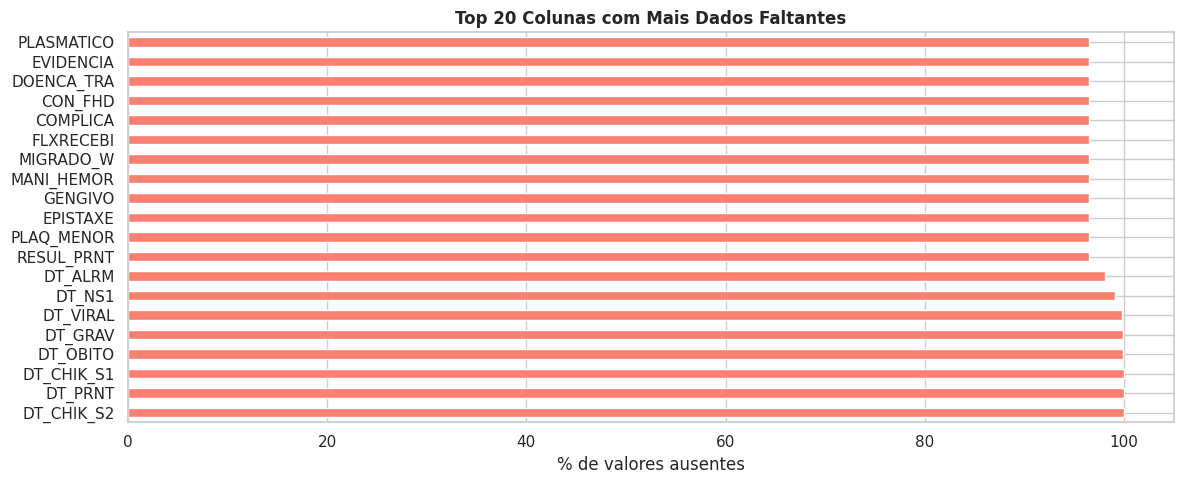


68 colunas têm mais de 50% de dados ausentes


In [3]:
# Percentual de valores ausentes por coluna (top 20)
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_top = missing[missing > 0].head(20)

fig, ax = plt.subplots(figsize=(12, 5))
missing_top.plot(kind='barh', ax=ax, color='salmon')
ax.set_xlabel('% de valores ausentes')
ax.set_title('Top 20 Colunas com Mais Dados Faltantes', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n{(missing > 50).sum()} colunas têm mais de 50% de dados ausentes")


## Análise Exploratória de Dados

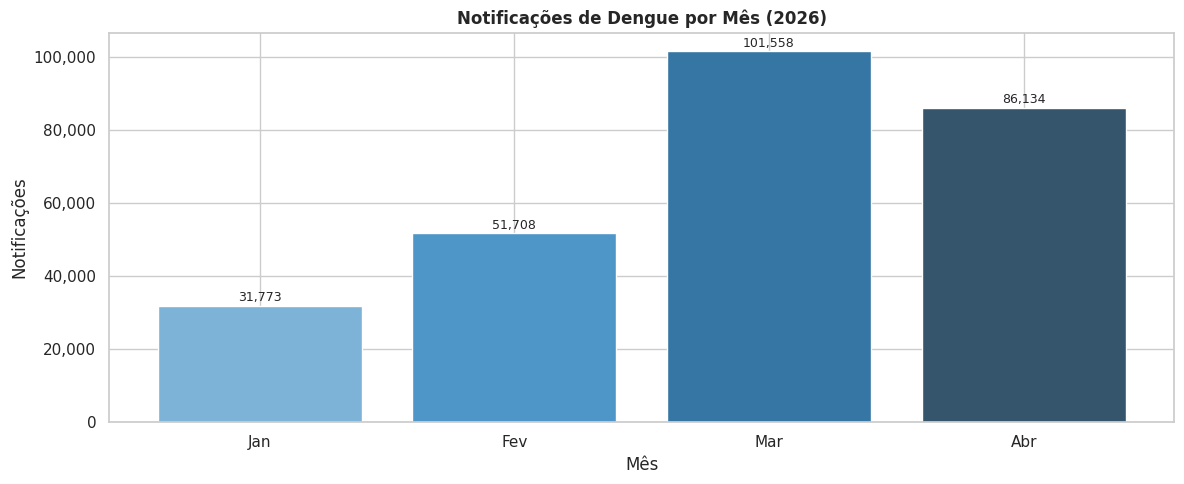

🔺 Mês com maior número de notificações: Mar (101,558 casos)


In [4]:
# Converter datas e criar coluna de mês
df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'], errors='coerce')
df['MES_NOT'] = df['DT_NOTIFIC'].dt.month
df['SEM_NOT_LABEL'] = df['SEM_NOT'].astype(str)

por_mes = df['MES_NOT'].value_counts().sort_index()
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, ax = plt.subplots()
bars = ax.bar(por_mes.index, por_mes.values, color=sns.color_palette('Blues_d', len(por_mes)))
ax.set_xticks(por_mes.index)
ax.set_xticklabels([meses[i-1] for i in por_mes.index])
ax.set_xlabel('Mês')
ax.set_ylabel('Notificações')
ax.set_title('Notificações de Dengue por Mês (2026)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(f"🔺 Mês com maior número de notificações: {meses[por_mes.idxmax()-1]} ({por_mes.max():,} casos)")


### Distribuição por Estado

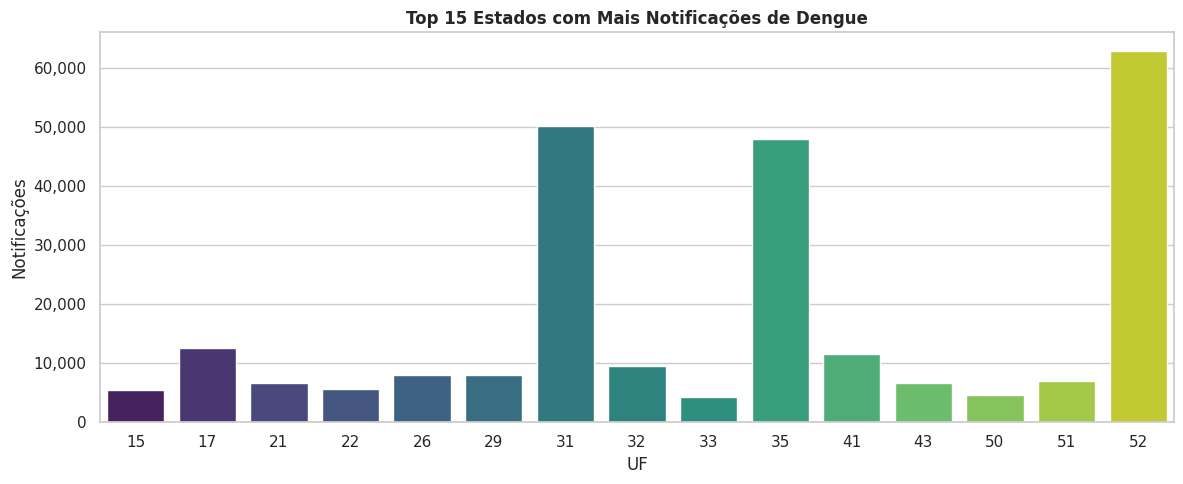

Top 5 estados:
 SG_UF_NOT
52    62960
31    50290
35    48021
17    12613
41    11629
Name: count, dtype: int64


In [5]:
por_uf = df['SG_UF_NOT'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=por_uf.index, y=por_uf.values, palette='viridis', ax=ax)
ax.set_xlabel('UF')
ax.set_ylabel('Notificações')
ax.set_title('Top 15 Estados com Mais Notificações de Dengue', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print("Top 5 estados:\n", por_uf.head())


### Perfil Demográfico

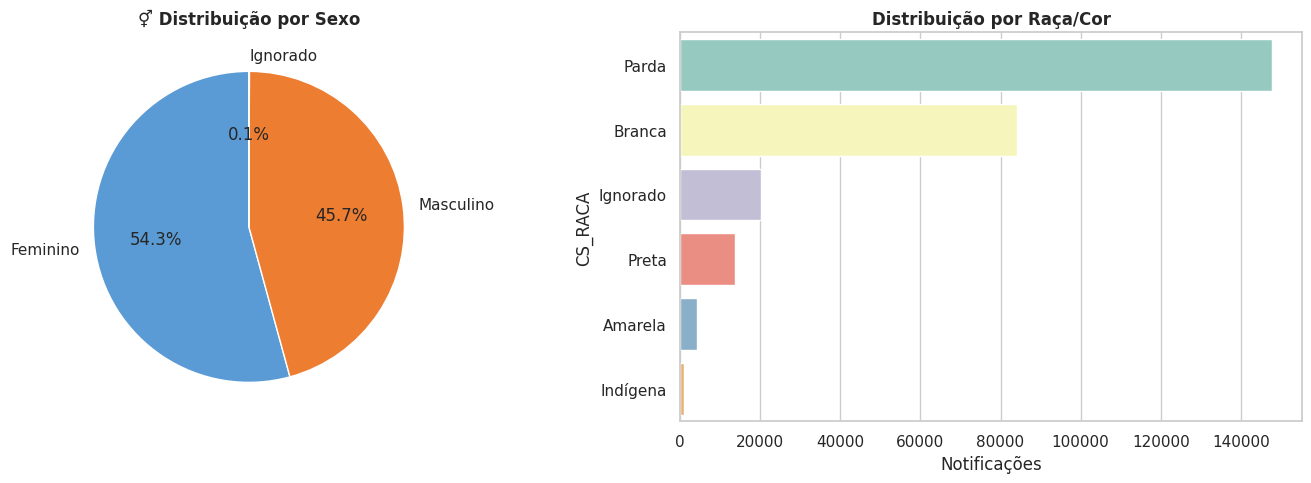

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sexo
sexo_map = {'M': 'Masculino', 'F': 'Feminino', 'I': 'Ignorado'}
sexo = df['CS_SEXO'].map(sexo_map).value_counts()
axes[0].pie(sexo.values, labels=sexo.index, autopct='%1.1f%%',
            colors=['#5B9BD5', '#ED7D31', '#A9A9A9'], startangle=90)
axes[0].set_title('⚥ Distribuição por Sexo', fontweight='bold')

# Raça / Cor
raca_map = {1:'Branca', 2:'Preta', 3:'Amarela', 4:'Parda', 5:'Indígena', 9:'Ignorado'}
raca = df['CS_RACA'].map(raca_map).value_counts()
sns.barplot(x=raca.values, y=raca.index, palette='Set3', ax=axes[1])
axes[1].set_xlabel('Notificações')
axes[1].set_title('Distribuição por Raça/Cor', fontweight='bold')

plt.tight_layout()
plt.show()


### Sintomas Mais Frequentes

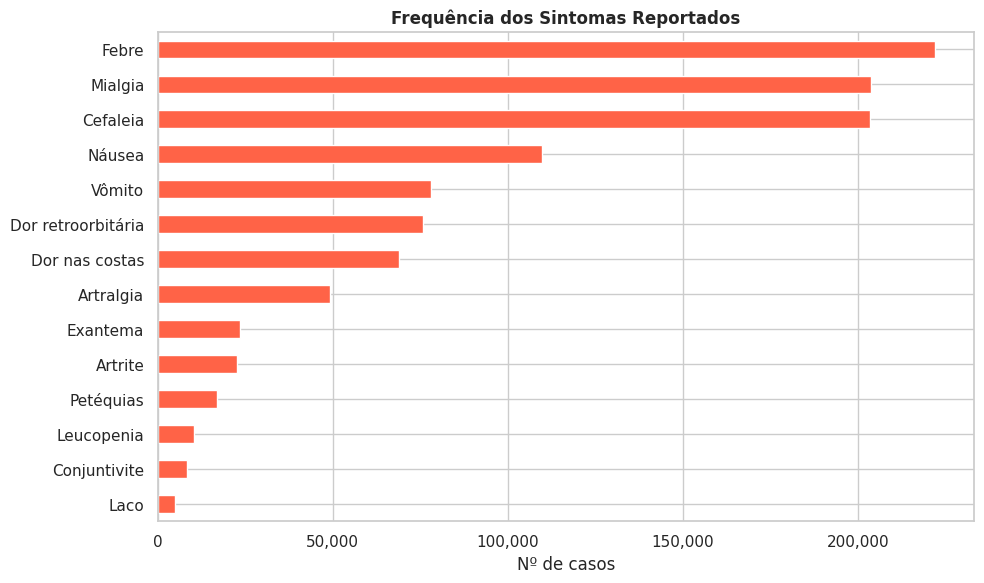

In [7]:
# Colunas de sintomas: valor 1 = sim
sintomas_cols = ['FEBRE','MIALGIA','CEFALEIA','EXANTEMA','VOMITO',
                 'NAUSEA','DOR_COSTAS','CONJUNTVIT','ARTRITE','ARTRALGIA',
                 'PETEQUIA_N','LEUCOPENIA','LACO','DOR_RETRO']

sintomas_nomes = {
    'FEBRE':'Febre', 'MIALGIA':'Mialgia', 'CEFALEIA':'Cefaleia',
    'EXANTEMA':'Exantema', 'VOMITO':'Vômito', 'NAUSEA':'Náusea',
    'DOR_COSTAS':'Dor nas costas', 'CONJUNTVIT':'Conjuntivite',
    'ARTRITE':'Artrite', 'ARTRALGIA':'Artralgia', 'PETEQUIA_N':'Petéquias',
    'LEUCOPENIA':'Leucopenia', 'LACO':'Laco', 'DOR_RETRO':'Dor retroorbitária'
}

freq_sint = {sintomas_nomes[c]: (df[c] == 1).sum() for c in sintomas_cols if c in df.columns}
freq_sint = pd.Series(freq_sint).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
freq_sint.plot(kind='barh', color='tomato', ax=ax)
ax.set_xlabel('Nº de casos')
ax.set_title('Frequência dos Sintomas Reportados', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


### Hospitalização e Evolução

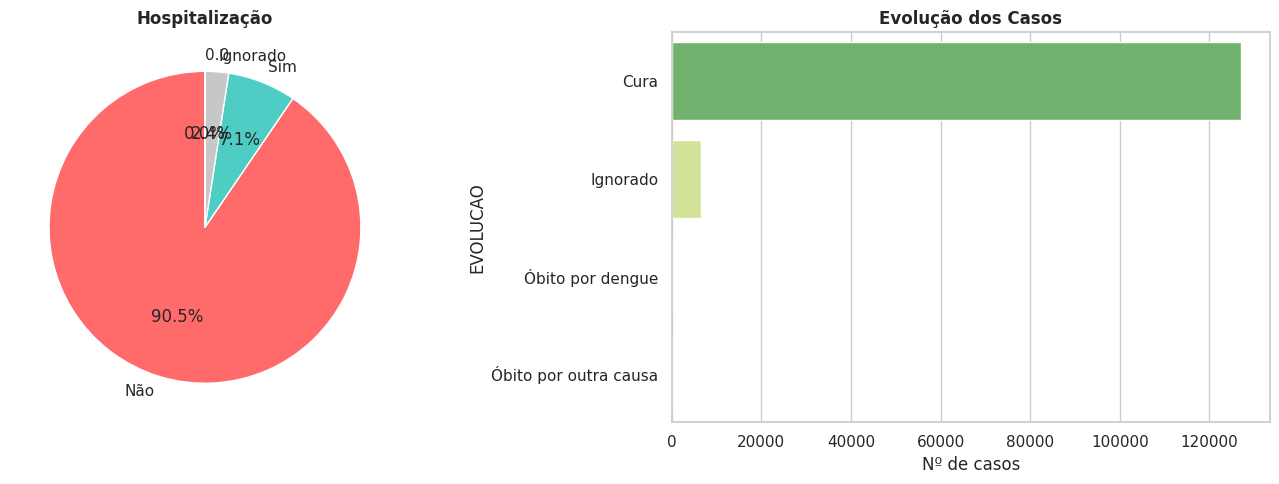

Óbitos por dengue confirmados : 91
Taxa de letalidade estimada  : 0.0336%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hospitalização
hosp = df['HOSPITALIZ'].value_counts()
hosp_map = {1:'Sim', 2:'Não', 9:'Ignorado'}
hosp.index = [hosp_map.get(i, str(i)) for i in hosp.index]
axes[0].pie(hosp.values, labels=hosp.index, autopct='%1.1f%%',
            colors=['#FF6B6B','#4ECDC4','#C7C7C7'], startangle=90)
axes[0].set_title('Hospitalização', fontweight='bold')

# Evolução do caso
evolucao_map = {1:'Cura', 2:'Óbito por dengue', 3:'Óbito por outra causa', 9:'Ignorado'}
evol = df['EVOLUCAO'].map(evolucao_map).value_counts()
sns.barplot(x=evol.values, y=evol.index, palette='RdYlGn_r', ax=axes[1])
axes[1].set_xlabel('Nº de casos')
axes[1].set_title('Evolução dos Casos', fontweight='bold')

plt.tight_layout()
plt.show()

# Taxa de letalidade
obitos = (df['EVOLUCAO'] == 2).sum()
total = len(df)
print(f"Óbitos por dengue confirmados : {obitos:,}")
print(f"Taxa de letalidade estimada  : {obitos/total*100:.4f}%")


### Classificação Final dos Casos

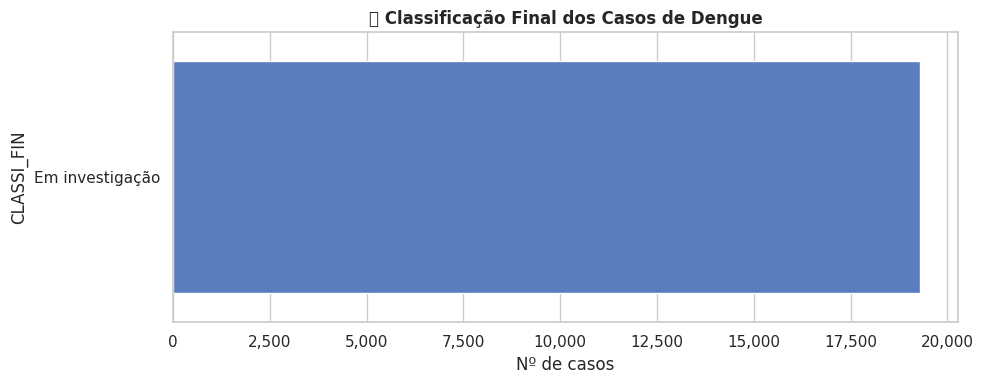

In [9]:
classi_map = {
    1: 'Dengue clássica',
    2: 'Dengue c/ complicação',
    3: 'Dengue grave',
    4: 'Descartado',
    5: 'Inconclusivo',
    8: 'Em investigação'
}
classi = df['CLASSI_FIN'].map(classi_map).value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=classi.values, y=classi.index, palette='muted', ax=ax)
ax.set_xlabel('Nº de casos')
ax.set_title('🔬 Classificação Final dos Casos de Dengue', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


### Distribuição por Faixa Etária

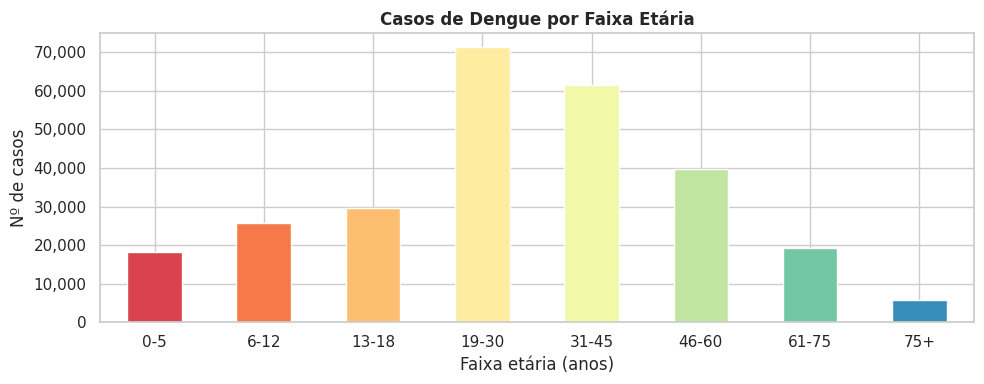

Média de idade: 31.8 anos
Mediana de idade: 29.0 anos


In [10]:


def decode_age(val):
    try:
        v = int(val)
        if v >= 4000: return v - 4000  # anos
        elif v >= 3000: return (v - 3000) / 12
        elif v >= 2000: return (v - 2000) / 365
        else: return 0
    except:
        return np.nan

df['IDADE_ANOS'] = df['NU_IDADE_N'].apply(decode_age)
df_idade = df[df['IDADE_ANOS'].between(0, 110)]

faixas = pd.cut(df_idade['IDADE_ANOS'],
                bins=[0,5,12,18,30,45,60,75,110],
                labels=['0-5','6-12','13-18','19-30','31-45','46-60','61-75','75+'])
faixa_count = faixas.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
faixa_count.plot(kind='bar', color=sns.color_palette('Spectral', len(faixa_count)), ax=ax, rot=0)
ax.set_xlabel('Faixa etária (anos)')
ax.set_ylabel('Nº de casos')
ax.set_title('Casos de Dengue por Faixa Etária', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f"Média de idade: {df_idade['IDADE_ANOS'].mean():.1f} anos")
print(f"Mediana de idade: {df_idade['IDADE_ANOS'].median():.1f} anos")
